In [ ]:
# choose 5 flightlines, side-by-side

In [1]:
import os
from glob import glob
import numpy as np
from spectral.io import envi
from spectral.io.envi import read_envi_header
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import box
import geopandas as gpd

# %matplotlib widget

In [2]:
home = '/store/carroll/col/data/2018/'
raw = home + 'raw/rmbl/'

igms = [x for x in glob(raw+'*/*_rdn_ort_igm.hdr', recursive=True)]
flightlines = [x.split('/')[-1].removesuffix('_rdn_ort_igm.hdr') for x in igms]

In [5]:
# prepare bbox gdf
campaign_bbox = gpd.read_file('/store/carroll/col/data/2018/raw/BoundingBox.kmz').to_crs(32613)

flightlines = glob('/store/carroll/col/data/2018/raw/rmbl/*/*_igm.hdr') # use the ort loc data
boxes = []
for fp in flightlines:
    flight = fp.split('/')[-1].removesuffix('_rdn_ort_igm.hdr') # to update with cluster file paths
    date = flight.split('_')[1]
    
    # get loc bounds
    loc = envi.open(fp).open_memmap()
    max_x = np.nanmax(loc[...,0])
    min_x = np.nanmin(loc[...,0])
    max_y = np.nanmax(loc[...,1])
    min_y = np.nanmin(loc[...,1])
    boxes.append({"flight": flight, "date": date, "geometry": box(min_x, min_y, max_x, max_y)})
gdf = gpd.GeoDataFrame(boxes, crs=32613)
gdf.to_file(os.path.join(raw, 'flightline_bboxes.geojson'))

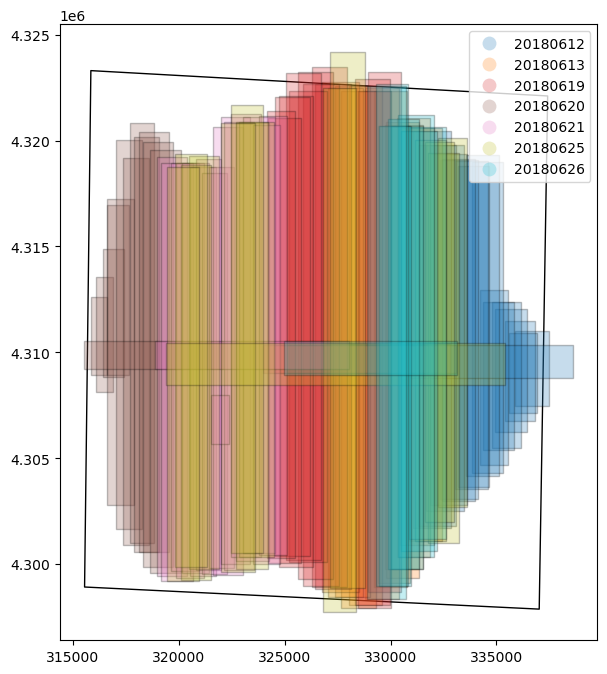

In [11]:
# viz
gdf = gpd.read_file(os.path.join(raw, 'flightline_bboxes.geojson'))

fig, ax = plt.subplots(figsize=(8,8))
campaign_bbox.plot(ax=ax, label='campaign', edgecolor='k', color='white')
gdf.plot(ax=ax, column="date", categorical=True, edgecolor="k", linewidth=1, legend=True, alpha = 0.25)
plt.show()

In [ ]:
# viz
gdf = gpd.read_file(os.path.join(raw, 'flightline_bboxes.geojson'))

fig, ax = plt.subplots(figsize=(8,8))
campaign_bbox.plot(ax=ax, edgecolor='k', color='white')
gdf.plot(ax=ax, column="date", categorical=True, edgecolor="k", linewidth=1, legend=True, alpha = 0.25)
plt.show()

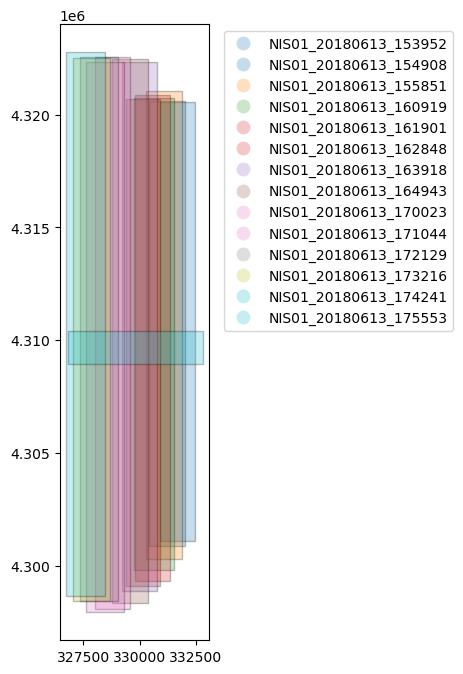

In [23]:
tmp = gdf.loc[gdf.date=='20180613',:]

fig, ax = plt.subplots(figsize=(8,8))
tmp.plot(ax=ax, column="flight", categorical=True, edgecolor="k", linewidth=1, legend=True, alpha = 0.25,
        legend_kwds={'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'})

plt.show()

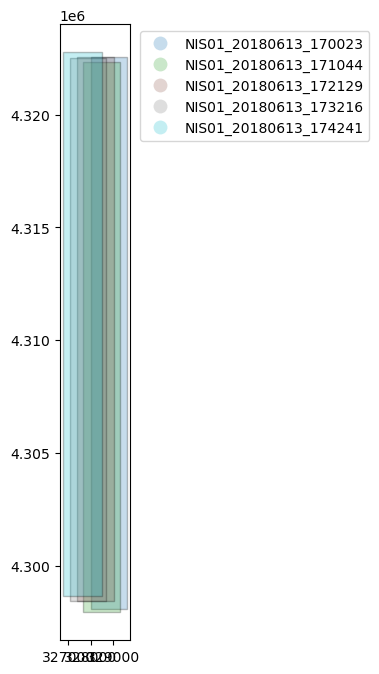

In [27]:
tmp = gdf.loc[gdf.date=='20180613',:]
tmp = tmp.iloc[-6:-1,:]

fig, ax = plt.subplots(figsize=(8,8))
tmp.plot(ax=ax, column="flight", categorical=True, edgecolor="k", linewidth=1, legend=True, alpha = 0.25,
        legend_kwds={'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'})

plt.show()

In [30]:
[x for x in tmp.flight]

['NIS01_20180613_170023',
 'NIS01_20180613_171044',
 'NIS01_20180613_172129',
 'NIS01_20180613_173216',
 'NIS01_20180613_174241']